In [58]:
from automata.fa.dfa import DFA
from automata.fa.nfa import NFA

In [59]:
regex_string = "[+=-]|[a-zA-Z]+[0-9]*|[0-9]+"

In [60]:
nfa_lexer = NFA.from_regex(regex_string)

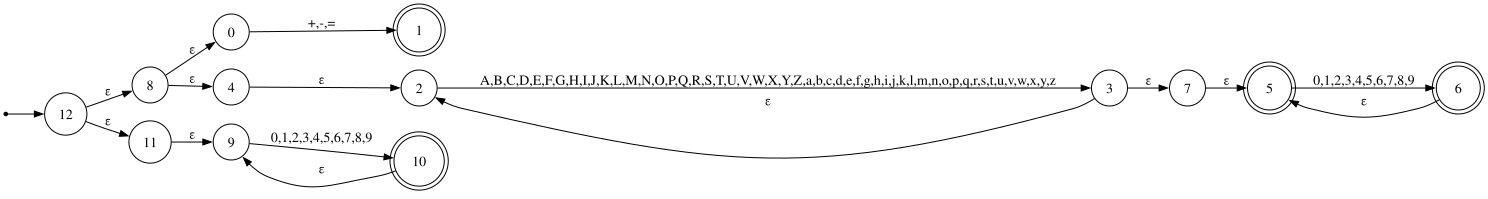

In [61]:
nfa_lexer.show_diagram(path="automata_pics/lexer_nfa.png")

In [62]:
nfa_lexer.accepts_input("=")

True

In [63]:
print(nfa_lexer.transitions)

frozendict.frozendict({0: frozendict.frozendict({'=': frozenset({1}), '+': frozenset({1}), '-': frozenset({1})}), 1: frozendict.frozendict({}), 2: frozendict.frozendict({'Y': frozenset({3}), 'Q': frozenset({3}), 'J': frozenset({3}), 'O': frozenset({3}), 'W': frozenset({3}), 'T': frozenset({3}), 'b': frozenset({3}), 'E': frozenset({3}), 'M': frozenset({3}), 'k': frozenset({3}), 'q': frozenset({3}), 'j': frozenset({3}), 'd': frozenset({3}), 'F': frozenset({3}), 'H': frozenset({3}), 'g': frozenset({3}), 'o': frozenset({3}), 'u': frozenset({3}), 'm': frozenset({3}), 'w': frozenset({3}), 'h': frozenset({3}), 'S': frozenset({3}), 'K': frozenset({3}), 'X': frozenset({3}), 'L': frozenset({3}), 'a': frozenset({3}), 'n': frozenset({3}), 'C': frozenset({3}), 'z': frozenset({3}), 'c': frozenset({3}), 't': frozenset({3}), 'l': frozenset({3}), 'i': frozenset({3}), 'G': frozenset({3}), 'Z': frozenset({3}), 'v': frozenset({3}), 'I': frozenset({3}), 'N': frozenset({3}), 'P': frozenset({3}), 'B': frozen

In [64]:
dfa_lexer = DFA.from_nfa(nfa_lexer)

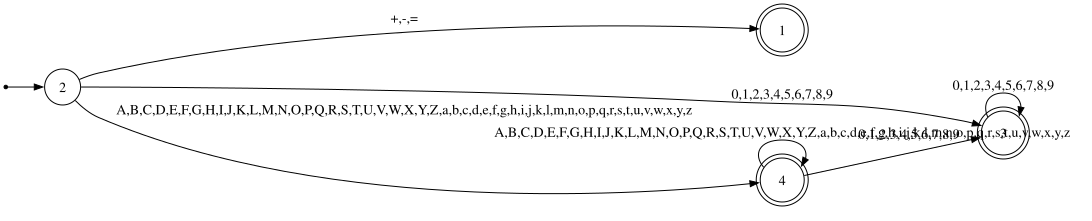

In [65]:
dfa_lexer.show_diagram(path="automata_pics/lexer_dfa.png")

In [66]:
minimized_dfa_lexer = dfa_lexer.minify()

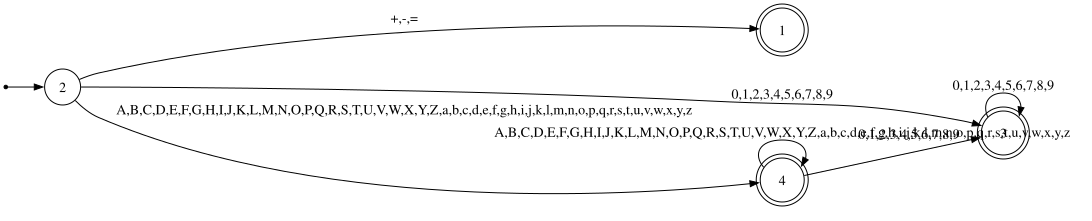

In [67]:
minimized_dfa_lexer.show_diagram(path="automata_pics/minimized_dfa_lexer.png")

In [68]:
minimized_dfa_lexer.accepts_input("hello334")

True

In [69]:
minimized_dfa_lexer.transitions

frozendict.frozendict({1: frozendict.frozendict({}), 2: frozendict.frozendict({'=': 1, '+': 1, '-': 1, 'Y': 4, 'Q': 4, 'J': 4, 'O': 4, 'W': 4, 'T': 4, 'b': 4, 'E': 4, 'M': 4, 'k': 4, 'q': 4, 'j': 4, 'd': 4, 'F': 4, 'H': 4, 'g': 4, 'o': 4, 'u': 4, 'm': 4, 'w': 4, 'h': 4, 'S': 4, 'K': 4, 'X': 4, 'L': 4, 'a': 4, 'n': 4, 'C': 4, 'z': 4, 'c': 4, 't': 4, 'l': 4, 'i': 4, 'G': 4, 'Z': 4, 'v': 4, 'I': 4, 'N': 4, 'P': 4, 'B': 4, 'A': 4, 'e': 4, 's': 4, 'y': 4, 'R': 4, 'V': 4, 'f': 4, 'x': 4, 'r': 4, 'U': 4, 'p': 4, 'D': 4, '1': 3, '3': 3, '6': 3, '4': 3, '7': 3, '0': 3, '9': 3, '5': 3, '2': 3, '8': 3}), 3: frozendict.frozendict({'1': 3, '3': 3, '6': 3, '4': 3, '7': 3, '0': 3, '9': 3, '5': 3, '2': 3, '8': 3}), 4: frozendict.frozendict({'Y': 4, 'Q': 4, 'J': 4, 'O': 4, 'W': 4, 'T': 4, 'b': 4, 'E': 4, 'M': 4, 'k': 4, 'q': 4, 'j': 4, 'd': 4, 'F': 4, 'H': 4, 'g': 4, 'o': 4, 'u': 4, 'm': 4, 'w': 4, 'h': 4, 'S': 4, 'K': 4, 'X': 4, 'L': 4, 'a': 4, 'n': 4, 'C': 4, 'z': 4, 'c': 4, 't': 4, 'l': 4, 'i': 4, '

In [70]:
minimized_dfa_lexer.initial_state

2

In [71]:
minimized_dfa_lexer.final_states

frozenset({1, 3, 4})

In [72]:
class Token:
    def __init__(self, type, input):
        self.type = type
        self.value = input

    def __str__(self):
        return f"Token : ({self.type}, {self.value})"

In [82]:
class TableDrivenLexer:
    def __init__(self,start_state,accept_states,transition,string):
        self.start_state = start_state
        self.accept_states = accept_states
        self.current_state = start_state
        self.transition = transition
        self.position = -1
        self.tokens = []
        self.lexeme = ""
        self.stack = []
        self.string = string
        self.previous_state = start_state
        self.last_accepted_type = None
        


    def next_char(self):
        self.position = self.position + 1
        if self.position < len(self.string):
            return self.string[self.position]
        else:
            return None

    def char_type(self):
        if self.current_state == 1:
            return "OPERATOR"
        elif self.current_state == 4:
            return "IDENTIFIER"
        elif self.current_state == 3:
            if self.last_accepted_type == "IDENTIFIER":
                return "IDENTIFIER"
            else:
                return "NUMBER"

    def skip_space(self):
        while self.position + 1 < len(self.string) and self.string[self.position + 1].isspace():
            self.position += 1

    

    def next_word(self):
        self.skip_space()

        if self.position + 1 >= len(self.string):
            return None

        start_position = self.position

        self.current_state = self.start_state
        self.lexeme = ""
        self.stack.clear()
        self.stack.append("BAD")

        while self.current_state is not None:
            
         
            c = self.next_char()

            if c is None or c.isspace():
                if c is not None:
                    self.position -= 1
                break
      
            

            self.lexeme = self.lexeme + c
          
            self.stack.append(self.current_state)
            self.previous_state = self.current_state
            state_transition = self.transition.get(self.current_state,{})
            self.current_state = state_transition.get(c)

            if self.current_state in self.accept_states:
                self.stack.clear()
                self.stack.append(self.current_state)
                self.last_accepted_type = self.char_type()
            


       

        while self.current_state not in self.accept_states and self.current_state != "BAD" :
            
            self.current_state = self.stack.pop()
            self.lexeme = self.lexeme[:-1]
            self.position -= 1

        if self.current_state in self.accept_states:
            return Token(self.last_accepted_type, self.lexeme)
        else:
            self.position = start_position + 1
            if self.position < len(self.string):
                bad_char = self.string[self.position]
            else:
                bad_char = "EOS"
            return Token("INVALID",bad_char)

    def lexing(self):
        
        while self.position + 1 < len(self.string):
            print(f"Current State: {self.current_state}")
            print(f"Previous State: {self.previous_state}")
            print(f"Last accepted token type: {self.last_accepted_type}")
            print(f"Stack: {self.stack}")
            token = self.next_word()
            if token:
                self.tokens.append(token)
        return self.tokens

       








                    
                    

            
                
                

            

            
         



In [77]:
lexer = TableDrivenLexer(minimized_dfa_lexer.initial_state, minimized_dfa_lexer.final_states, minimized_dfa_lexer.transitions,"x = x - 7 abc43 = 56")

In [80]:
lexer.lexing()

In [81]:
for token in lexer.tokens:
    print(token)

Token : (IDENTIFIER, x)
Token : (OPERATOR, =)
Token : (IDENTIFIER, x)
Token : (OPERATOR, -)
Token : (NUMBER, 7)
Token : (IDENTIFIER, abc43)
Token : (OPERATOR, =)
Token : (NUMBER, 56)


In [203]:
class DirectCodedLexer:
    def __init__(self,start_state,finish_states,string):
        self.start_state = start_state
        self.finish_states = finish_states
        self.stack = []
        self.string = string
        self.lexeme = ""
        self.current_state = start_state
        self.position = -1
        self.type = {
            1 : "OPERATOR",
            2 : "INVALID",
            3 : "INTEGER",
            4 : "IDENTIFIER"
        }
        self.tokens = []

    def nextChar(self):
        self.position += 1
        if self.position < len(self.string):
            return self.string[self.position]
        else:
            return None
        
    def skipspace(self):
        while self.position + 1  < len(self.string) and self.string[self.position + 1].isspace():
            self.position += 1 

    def nextword(self):
        
        self.skipspace()
        
        self.lexeme = ""
        self.stack.clear()
        self.stack.append("BAD")
        self.current_state = self.start_state

        

        while self.current_state is not None:
            c = self.nextChar()
            if c is None or c.isspace():
                if c is not None:
                    self.position -= 1
                break


            self.lexeme += c
            
            if self.current_state in self.finish_states:
                self.stack.clear()
            self.stack.append(self.current_state)
            
            
            match self.current_state:
                case 2:
                    if c == "+" or c == "-" or c == "=":
                        self.current_state = 1
                    elif c.isdigit():
                        self.current_state = 3
                    elif c.isalpha():
                        self.current_state = 4
                    else:
                        self.current_state = None
                case 1:
                    if c == "+" or c == "-" or c == "=":
                        self.current_state = 1
                    elif c.isdigit():
                        self.current_state = None
                    elif c.isalpha():
                        self.current_state = None
                    else:
                        self.current_state = None
                case 3:
                    if c == "+" or c == "-" or c == "=":
                        self.current_state = None
                    elif c.isdigit():
                        self.current_state = 3
                    elif c.isalpha():
                        self.current_state = None
                    else:
                        self.current_state = None
                case 4:
                     if c == "+" or c == "-" or c == "=":
                        self.current_state = None
                     elif c.isdigit():
                        self.current_state = 4
                     elif c.isalpha():
                        self.current_state = 4
                     else:
                        self.current_state = None

        while self.current_state not in self.finish_states and self.current_state != "BAD":
            if self.stack[0] == "BAD":
                raise Exception("Invalid character detcted")
            self.current_state = self.stack.pop()
            self.lexeme = self.lexeme[:-1]
            self.position -= 1
            

        if self.current_state in self.finish_states:
            token_type = self.type.get(self.current_state,{})
            token = Token(token_type, self.lexeme)
            return token

    def lexing(self):
        while self.position + 1  < len(self.string):
            token = self.nextword()
            if token is not None:
                self.tokens.append(token)
        return self.tokens


        



                                    
        

        

In [204]:
lexer2 = DirectCodedLexer(minimized_dfa_lexer.initial_state, minimized_dfa_lexer.final_states, "abc45 = 67 + 56")

In [205]:
tokens = lexer2.lexing()
for token in tokens:
    print(token)

Token : (IDENTIFIER, abc45)
Token : (OPERATOR, =)
Token : (INTEGER, 67)
Token : (OPERATOR, +)
Token : (INTEGER, 56)
